# 1D Heat Equation — Chebyshev Pseudospectral Solver with Non-Uniform Boundary Conditions

This notebook demonstrates `ModelSpectralSolver` with `bc="chebyshev"` on a problem
where the two Dirichlet boundaries hold **different, non-zero values**.

## Problem

$$u_t = \nu\, u_{xx}, \quad x \in [-1, 1],\; t \in [0, T]$$

**Non-uniform (asymmetric) Dirichlet BCs:**
$$u(-1,\, t) = T_L = 0 \quad\text{(cold wall)}, \qquad u(+1,\, t) = T_R = 1 \quad\text{(hot wall)}$$

**Initial condition:**
$$u(x,\, 0) = \frac{1+x}{2} + A\,\sin\!\left(\frac{\pi(x+1)}{2}\right)$$

## Strategy — Tau Method (direct, no lifting)

We solve for $u$ directly. The **tau method** freezes the boundary nodes by zeroing
rows 0 and $N-1$ of the $\nu D^2$ matrix. As long as the initial condition already
satisfies the BCs ($u_0(\pm1) = T_{L/R}$), those rows are never updated and the
boundary values remain fixed for all time.

## Exact Solution

The steady state is the linear profile $(1+x)/2$.  The transient is a damped sine mode:

$$u(x,\, t) = \frac{1+x}{2} + A\,\sin\!\left(\frac{\pi(x+1)}{2}\right) e^{-\nu(\pi/2)^2\, t}$$


## 1 — Import Required Libraries

In [1]:
import pinns

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


## 2 — Physical Parameters and Time Grid

In [2]:
# ── Physical parameters ───────────────────────────────────────────────────────
nu    = 0.1        # diffusion coefficient
N     = 128        # Chebyshev–Gauss–Lobatto nodes (includes both endpoints)
dt    = 1e-2       # ETD2RK time step  (also defines output resolution)
t_end = 1.0
A     = 1.0        # amplitude of initial perturbation

# ── Non-uniform (asymmetric) Dirichlet boundary conditions ───────────────────
T_L = 0.0   # cold wall at x = -1
T_R = 1.0   # hot  wall at x = +1

print(f"BCs: u(-1,t) = {T_L}, u(+1,t) = {T_R}")
print(f"Steady state: linear profile from {T_L} to {T_R}")

BCs: u(-1,t) = 0.0, u(+1,t) = 1.0
Steady state: linear profile from 0.0 to 1.0


## 3 — Build the Chebyshev Spectral Solver

`ModelSpectralSolver` with `bc="chebyshev"` automatically:
- Places $N$ **Gauss–Lobatto nodes** $x_j = -\cos\!\left(\tfrac{j\pi}{N-1}\right)$ on $[-1,1]$.
- Builds the **Chebyshev differentiation matrix** $D$ (shape $N\times N$), accessible as `model.k` / `model.D`.
- Sets `forward` / `inverse` to the **identity** (collocation basis = physical space).

The linear operator receives the full $D$ matrix as `X` and returns a dense matrix per
state, so `_detect_linear_diagonal` automatically selects the **matrix-exponential** path
inside ETD2RK — no special code needed.

In [3]:
domain = pinns.DomainCubic(
    space=[(-1.0, 1.0)],
    time=(0.0, t_end),
)

integrator = pinns.IntegratorETD2RK(dt=dt)

# bc="chebyshev" → Gauss-Lobatto grid, D matrix, identity forward/inverse
model = pinns.ModelSpectralSolver(
    domain, ["u"], integrator, shape=N, bc="chebyshev"
)

# Physical Gauss-Lobatto nodes on [-1, 1]
x_gl = np.asarray(model.x)   # (N,)

print(f"Grid nodes (N={N}):")
print(np.round(x_gl, 4))
print(f"\nD matrix shape: {model.D.shape}")

Grid nodes (N=128):
[-1.     -0.9997 -0.9988 -0.9972 -0.9951 -0.9924 -0.989  -0.985  -0.9805
 -0.9753 -0.9696 -0.9632 -0.9563 -0.9487 -0.9406 -0.9319 -0.9227 -0.9129
 -0.9025 -0.8916 -0.8801 -0.8681 -0.8555 -0.8425 -0.8289 -0.8148 -0.8002
 -0.7851 -0.7696 -0.7535 -0.737  -0.7201 -0.7027 -0.6849 -0.6667 -0.648
 -0.629  -0.6096 -0.5898 -0.5696 -0.5491 -0.5283 -0.5071 -0.4857 -0.4639
 -0.4418 -0.4195 -0.3969 -0.3741 -0.351  -0.3278 -0.3043 -0.2807 -0.2568
 -0.2328 -0.2087 -0.1845 -0.1601 -0.1356 -0.1111 -0.0865 -0.0618 -0.0371
 -0.0124  0.0124  0.0371  0.0618  0.0865  0.1111  0.1356  0.1601  0.1845
  0.2087  0.2328  0.2568  0.2807  0.3043  0.3278  0.351   0.3741  0.3969
  0.4195  0.4418  0.4639  0.4857  0.5071  0.5283  0.5491  0.5696  0.5898
  0.6096  0.629   0.648   0.6667  0.6849  0.7027  0.7201  0.737   0.7535
  0.7696  0.7851  0.8002  0.8148  0.8289  0.8425  0.8555  0.8681  0.8801
  0.8916  0.9025  0.9129  0.9227  0.9319  0.9406  0.9487  0.9563  0.9632
  0.9696  0.9753  0.9805  0.985 

## 4 — Set Linear and Nonlinear Operators

The PDE is:

$$u_t = \underbrace{\nu D^2\, u}_{\text{linear}}$$

**Linear operator** — $\nu D^2$ with **tau rows zeroed** to enforce the BCs:

| Row | Node | Action |
|-----|------|--------|
| 0   | $x = -1$ | zeroed → $u(-1)$ is never updated, stays at $T_L$ |
| N-1 | $x = +1$ | zeroed → $u(+1)$ is never updated, stays at $T_R$ |

The initial condition must already satisfy the BCs for this to work.
There is no nonlinear term, so `set_nonlinear_op` is not needed.


In [4]:
import jax.numpy as jnp

def linear_op(X, p):
    """ν D² with boundary rows zeroed (tau method)."""
    D = X
    L = p["nu"] * (D @ D)
    L = L.at[0,  :].set(0.0)   # freeze u(-1) = T_L
    L = L.at[-1, :].set(0.0)   # freeze u(+1) = T_R
    return {"u": L}

# Pure diffusion — no nonlinear term needed
model.set_linear_op(linear_op)
model.add_parameter("nu", nu)

print("Operators registered.")

Operators registered.


## 5 — Initial Condition and Time Integration

$$u_0(x) = \frac{1+x}{2} + A\,\sin\!\left(\tfrac{\pi(x+1)}{2}\right)$$

The boundary values are already correct: $u_0(-1) = 0 = T_L$, $u_0(+1) = 1 = T_R$.
The tau method then keeps them frozen throughout the integration.


In [ ]:
x_gl = np.asarray(model.x)   # (N,) Gauss-Lobatto nodes

# Full initial condition: steady profile + perturbation
u0 = (1.0 + x_gl) / 2.0 + A * np.sin(np.pi * (x_gl + 1.0) / 2.0)
Dices de
# Verify BCs are satisfied in the initial condition
print(f"u0(-1) = {u0[0]:.6f}  (should be {T_L})")
print(f"u0(+1) = {u0[-1]:.6f}  (should be {T_R})")

model.add_initial(jnp.array(u0))

U_sol = model.solve()          # observation times = linspace(0, t_end, N_steps+1)
U_num = np.asarray(U_sol["u"]) # (Nt, N)

# Recover the time grid that the integrator used (for plotting/comparison)
t_obs = integrator._get_obs_times(model)

print(f"\nSolution shape: {U_num.shape}  ({len(t_obs)} snapshots)")
print(f"u(-1, t) range: [{U_num[:, 0].min():.6f}, {U_num[:, 0].max():.6f}]  (should be {T_L})")
print(f"u(+1, t) range: [{U_num[:,-1].min():.6f}, {U_num[:,-1].max():.6f}]  (should be {T_R})")

u0(-1) = 0.000000  (should be 0.0)
u0(+1) = 1.000000  (should be 1.0)

Solution shape: (101, 128)  (101 snapshots)
u(-1, t) range: [0.000000, 0.000185]  (should be 0.0)
u(+1, t) range: [1.000000, 1.000000]  (should be 1.0)


## 6 — Comparison with Exact Solution

$$u(x,\,t) = \frac{1+x}{2} + A\,\sin\!\left(\frac{\pi(x+1)}{2}\right)e^{-\nu(\pi/2)^2 t}$$


In [6]:
g      = (1.0 + x_gl) / 2.0                                    # (N,) steady state
decay  = np.exp(-nu * (np.pi / 2.0)**2 * t_obs)               # (Nt,)
mode   = A * np.sin(np.pi * (x_gl + 1.0) / 2.0)               # (N,)
U_exact = g[None, :] + decay[:, None] * mode[None, :]         # (Nt, N)

abs_err = np.abs(U_num - U_exact)
rel_err = abs_err.max() / np.abs(U_exact).max()
print(f"Max absolute error : {abs_err.max():.2e}")
print(f"Max relative error : {rel_err:.2e}")

Max absolute error : 6.35e-03
Max relative error : 4.10e-03


## 7 — Visualization


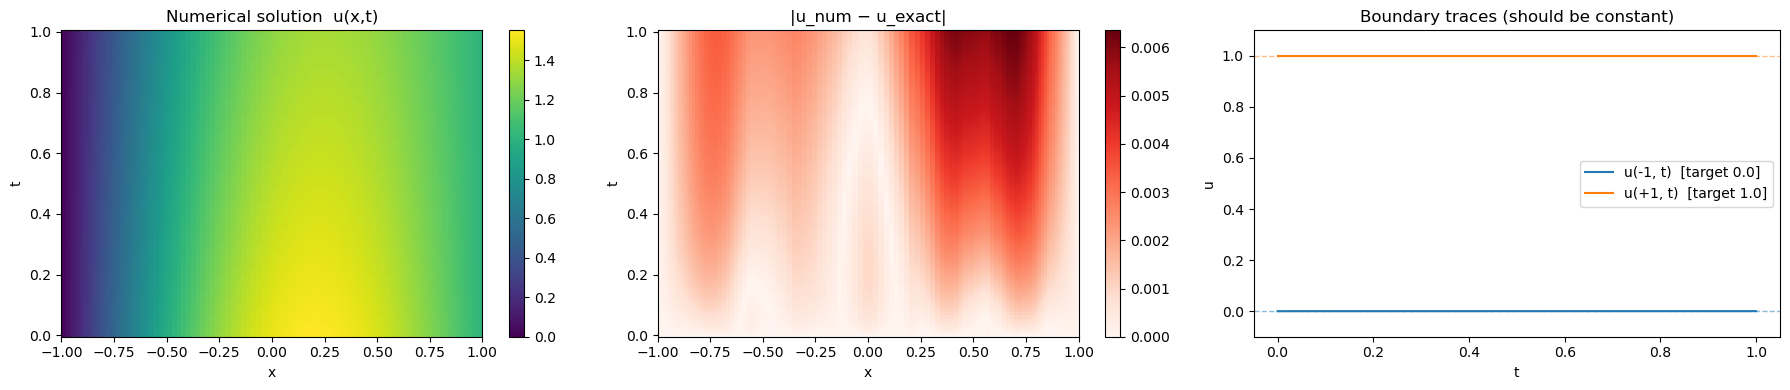

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

im = axes[0].pcolormesh(x_gl, t_obs, U_num, cmap="viridis", shading="auto")
axes[0].set_xlabel("x")
axes[0].set_ylabel("t")
axes[0].set_title("Numerical solution  u(x,t)")
plt.colorbar(im, ax=axes[0])

im2 = axes[1].pcolormesh(x_gl, t_obs, abs_err, cmap="Reds", shading="auto")
axes[1].set_xlabel("x")
axes[1].set_ylabel("t")
axes[1].set_title("|u_num − u_exact|")
plt.colorbar(im2, ax=axes[1])

axes[2].plot(t_obs, U_num[:, 0],  color="C0", label=f"u(-1, t)  [target {T_L}]")
axes[2].plot(t_obs, U_num[:, -1], color="C1", label=f"u(+1, t)  [target {T_R}]")
axes[2].axhline(T_L, ls="--", lw=1, color="C0", alpha=0.5)
axes[2].axhline(T_R, ls="--", lw=1, color="C1", alpha=0.5)
axes[2].set_xlabel("t")
axes[2].set_ylabel("u")
axes[2].set_title("Boundary traces (should be constant)")
axes[2].legend()
axes[2].set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.show()